In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
df = pd.read_parquet('../data/customer churn/merged_data.parquet')
data = pd.read_parquet('../data/customer churn/clean_data.parquet')

In [16]:
df.columns[df.isnull().sum()>0]
df.internet_type.fillna(method='ffill', axis=0, inplace=True)
df.internet_type.fillna(method='bfill', axis=0, inplace=True)
df.columns[df.isnull().sum()>0]

Index(['offer', 'churn_reason'], dtype='object')

In [62]:
df['monthly_charges'] = df['monthly_ charges']

In [28]:
group_internet = df[['internet_type', 'monthly_ charges', 'avg_monthly_long_distance_charges', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_revenue']].groupby('internet_type')

In [21]:
df[['monthly_ charges', 'avg_monthly_long_distance_charges', 'total_revenue']]

,monthly_ charges,avg_monthly_long_distance_charges,total_revenue
0,65.60,42.39,974.81
1,59.90,10.69,610.28
2,73.90,33.65,415.45
3,98.00,27.82,1599.51
4,83.90,7.38,289.54
...,...,...,...
7038,55.15,46.68,1349.74
7039,85.10,16.20,2230.10
7040,50.30,18.62,129.99
7041,67.85,2.12,4769.69


In [38]:
group_internet.sum()

,monthly_ charges,avg_monthly_long_distance_charges,total_charges,total_refunds,total_extra_data_charges,total_revenue
internet_type,,,,,,
Cable,54690.8,21026.89,1882150.75,1752.69,6340,2546845.25
DSL,104948.2,41295.14,3794483.60,4091.77,15620,5159749.06
Fiber Optic,296477.6,99377.88,10384090.89,7975.19,26360,13664537.38


In [66]:
new_df = df[['internet_type', 'monthly_charges', 'avg_monthly_long_distance_charges', 'total_revenue']]
group1 = new_df[['monthly_charges', 'avg_monthly_long_distance_charges', 'total_revenue']][new_df['internet_type']=='Fiber Optic']
group2 = new_df[['monthly_charges', 'avg_monthly_long_distance_charges', 'total_revenue']][new_df['internet_type']=='Cable']
group3 = new_df[['monthly_charges', 'avg_monthly_long_distance_charges', 'total_revenue']][new_df['internet_type']=='DSL']

In [67]:
group1_mc = new_df['monthly_charges'][new_df['internet_type']=='Fiber Optic']
group2_mc = new_df['monthly_charges'][new_df['internet_type']=='Cable']
group3_mc = new_df['monthly_charges'][new_df['internet_type']=='DSL']

In [68]:
# !pip install statsmodels

In [69]:
from scipy import stats
import statsmodels.formula.api as sm
import statsmodels.stats.anova as anova
f_stat, p_value = stats.f_oneway(group1_mc, group2_mc, group3_mc)
print(f_stat)
print(p_value)
if p_value<0.05:
    print('statistically significant difference')

680.8615925887415
4.77642338260073e-271
statistically significant difference


In [74]:
model = sm.ols('total_extra_data_charges ~ C(internet_type)', data=df).fit()
anova_table = anova.anova_lm(model, typ=2)
print("\nStatsmodels Monthly Charges")
print(anova_table)


Statsmodels Monthly Charges
                        sum_sq      df         F    PR(>F)
C(internet_type)  1.793171e+03     2.0  1.422735  0.241123
Residual          4.436497e+06  7040.0       NaN       NaN


In [73]:
model = sm.ols('total_revenue ~ C(internet_type)', data=df).fit()
anova_table = anova.anova_lm(model, typ=2)
print("\nStatsmodels Long Distance Charges")
print(anova_table)


Statsmodels Long Distance Charges
                        sum_sq      df           F        PR(>F)
C(internet_type)  1.781339e+09     2.0  111.911441  1.425917e-48
Residual          5.602924e+10  7040.0         NaN           NaN


# <span style='color:red'>total refund and total extra charges are only which not does not have much difference across all three internet types</span>
# <span style='color:red'>all other charges have major difference between them with cable->DSL->fiber optic from least to most</span>

In [75]:
df

,customer_id,gender,age,under_30,senior_citizen,partner,dependents,number_of_dependents,married,country,state,city,zip_code,total_population,latitude,longitude,phone_service,internet_service,online_security,online_backup,device_protection,premium_tech_support,streaming_tv,streaming_movies,streaming_music,internet_type,contract,paperless_billing,payment_method,monthly_ charges,avg_monthly_long_distance_charges,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,tenure,multiple_lines,avg_monthly_gb_download,unlimited_data,offer,referred_a_friend,number_of_referrals,satisfaction_score,cltv,customer_status,churn_score,churn_label,churn_value,churn_category,churn_reason,monthly_charges
0,0002-ORFBO,Female,37,No,No,Yes,No,0,Yes,United States,California,Frazier Park,93225,4498,34.827662,-118.999073,Yes,Yes,No,Yes,No,Yes,Yes,No,No,Cable,One Year,Yes,Mailed check,65.60,42.39,593.30,0.00,0,381.51,974.81,9,No,16,Yes,None,Yes,2,3,2205,Stayed,65,No,0,Not Applicable,None,65.60
1,0003-MKNFE,Male,46,No,No,No,No,0,No,United States,California,Glendale,91206,31297,34.162515,-118.203869,Yes,Yes,No,No,No,No,No,Yes,Yes,Cable,Month-to-Month,No,Mailed check,59.90,10.69,542.40,38.33,10,96.21,610.28,9,Yes,10,No,None,No,0,5,5414,Stayed,66,No,0,Not Applicable,None,59.90
2,0004-TLHLJ,Male,50,No,No,No,No,0,No,United States,California,Costa Mesa,92627,62069,33.645672,-117.922613,Yes,Yes,No,No,Yes,No,No,No,No,Fiber Optic,Month-to-Month,Yes,Electronic check,73.90,33.65,280.85,0.00,0,134.60,415.45,4,No,30,Yes,Offer E,No,0,1,4479,Churned,71,Yes,1,Competitor,Competitor had better devices,73.90
3,0011-IGKFF,Male,78,No,Yes,Yes,No,0,Yes,United States,California,Martinez,94553,46677,38.014457,-122.115432,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,Fiber Optic,Month-to-Month,Yes,Electronic check,98.00,27.82,1237.85,0.00,0,361.66,1599.51,13,No,4,Yes,Offer D,Yes,1,1,3714,Churned,91,Yes,1,Dissatisfaction,Product dissatisfaction,98.00
4,0013-EXCHZ,Female,75,No,Yes,Yes,No,0,Yes,United States,California,Camarillo,93010,42853,34.227846,-119.079903,Yes,Yes,No,No,No,Yes,Yes,No,No,Fiber Optic,Month-to-Month,Yes,Mailed check,83.90,7.38,267.40,0.00,0,22.14,289.54,3,No,11,Yes,None,Yes,3,1,3464,Churned,68,Yes,1,Dissatisfaction,Network reliability,83.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,Female,20,Yes,No,No,No,0,No,United States,California,La Mesa,91941,44652,32.759327,-116.997260,Yes,Yes,Yes,No,No,Yes,No,No,Yes,DSL,One Year,No,Mailed check,55.15,46.68,742.90,0.00,0,606.84,1349.74,13,No,59,Yes,Offer D,No,0,4,3161,Stayed,59,No,0,Not Applicable,None,55.15
7039,9992-RRAMN,Male,40,No,No,Yes,No,0,Yes,United States,California,Riverbank,95367,16525,37.734971,-120.954271,Yes,Yes,No,No,No,No,No,Yes,Yes,Fiber Optic,Month-to-Month,Yes,Electronic check,85.10,16.20,1873.70,0.00,0,356.40,2230.10,22,Yes,17,Yes,Offer D,Yes,1,1,5248,Churned,68,Yes,1,Dissatisfaction,Product dissatisfaction,85.10
7040,9992-UJOEL,Male,22,Yes,No,No,No,0,No,United States,California,Elk,95432,383,39.108252,-123.645121,Yes,Yes,No,Yes,No,No,No,No,No,DSL,Month-to-Month,Yes,Mailed check,50.30,18.62,92.75,0.00,0,37.24,129.99,2,No,51,Yes,Offer E,No,0,5,5870,Joined,33,No,0,Not Applicable,None,50.30
7041,9993-LHIEB,Male,21,Yes,No,Yes,No,0,Yes,United States,California,Solana Beach,92075,12173,33.001813,-117.263628,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Cable,Two Year,No,Mailed check,67.85,2.12,4627.65,0.00,0,142.04,4769.69,67,No,58,Yes,Offer A,Yes,5,3,4792,Stayed,59,No,0,Not Applicable,None,67.85


In [78]:
cltv_df = df[['cltv','churn_score']]

In [79]:
pearson_f, p_vlaue = stats.pearsonr(df['cltv'], df['churn_score'])

In [82]:
print(pre_f)
print(p_value)

-0.07923235584870471
4.77642338260073e-271


In [81]:
p_value

4.77642338260073e-271

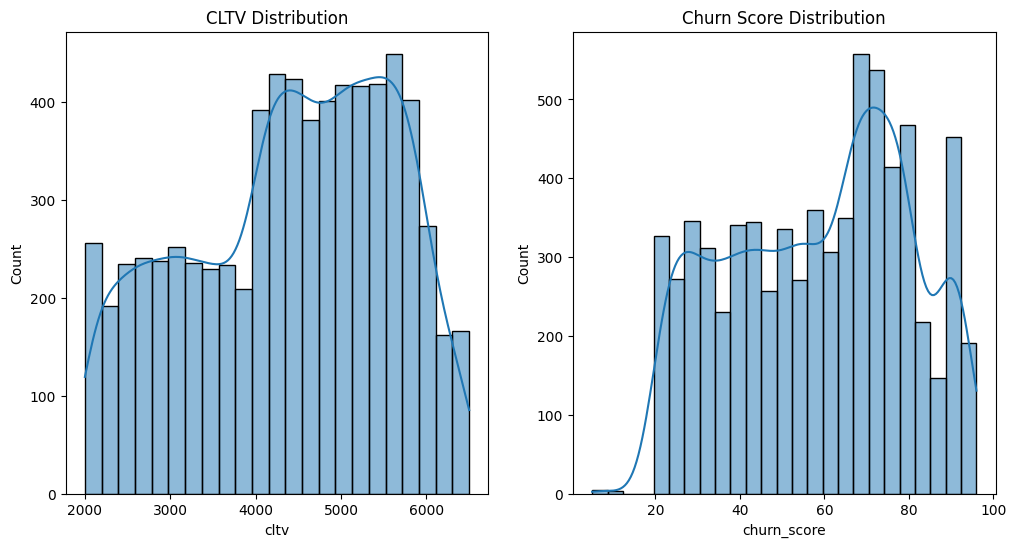

/home/harsh/lab/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7043.
  res = hypotest_fun_out(*samples, **kwds)


CLTV Shapiro-Wilk: ShapiroResult(statistic=0.9618037697341285, pvalue=1.5858152144776188e-39)
Churn Shapiro-Wilk: ShapiroResult(statistic=0.9607759105933785, pvalue=6.255945391357611e-40)

Original Data:
Pearson: PearsonRResult(statistic=-0.07923235584870471, pvalue=2.7631002698576396e-11)
Spearman: SignificanceResult(statistic=-0.07941428933094699, pvalue=2.4890402187821637e-11)


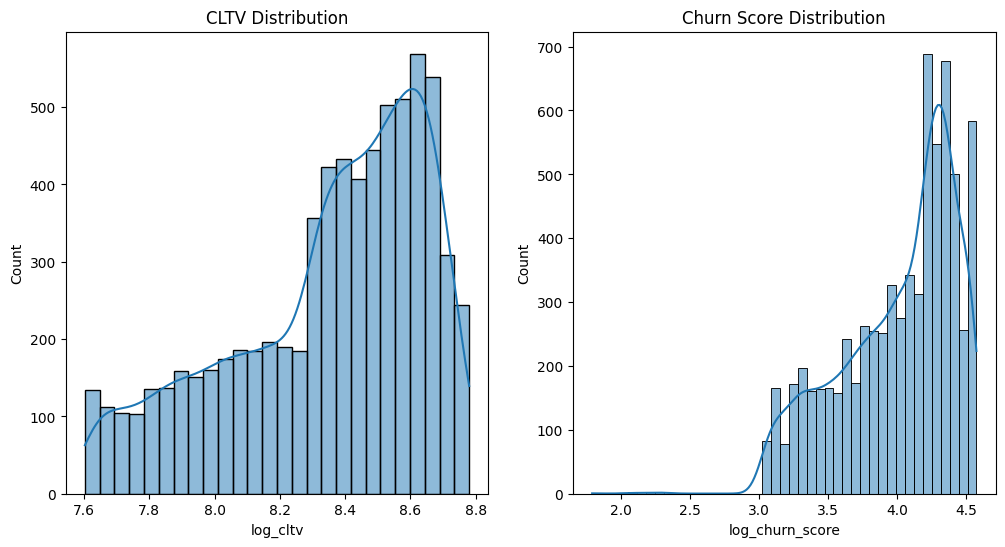

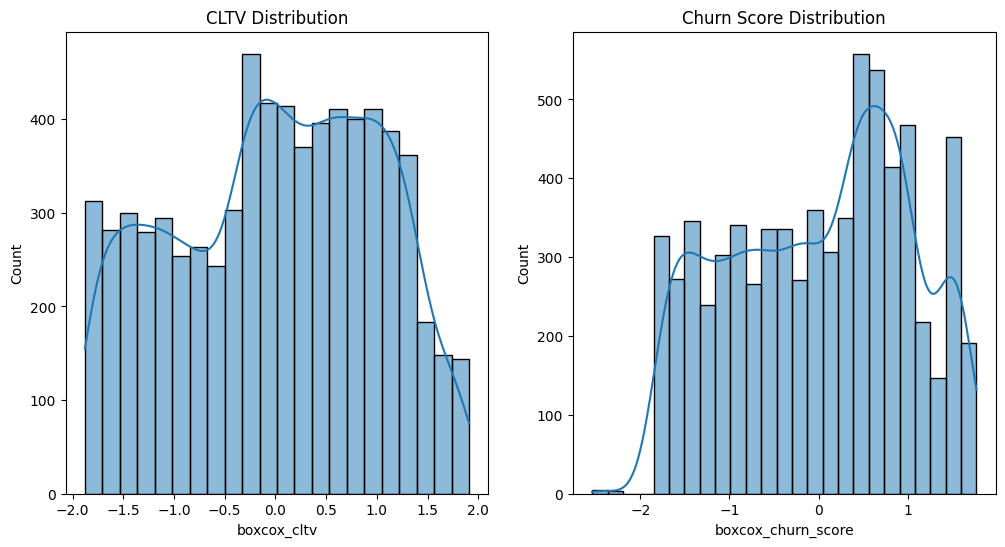


After Log Transformation and Scaling:
Pearson: PearsonRResult(statistic=-0.07808248293894667, pvalue=5.318346701328155e-11)
Spearman: SignificanceResult(statistic=-0.07941428933094699, pvalue=2.4890402187821637e-11)

After Box-Cox Transformation and Scaling:
Pearson: PearsonRResult(statistic=-0.07911552673522823, pvalue=2.954434898453239e-11)
Spearman: SignificanceResult(statistic=-0.07941428933094699, pvalue=2.4890402187821637e-11)


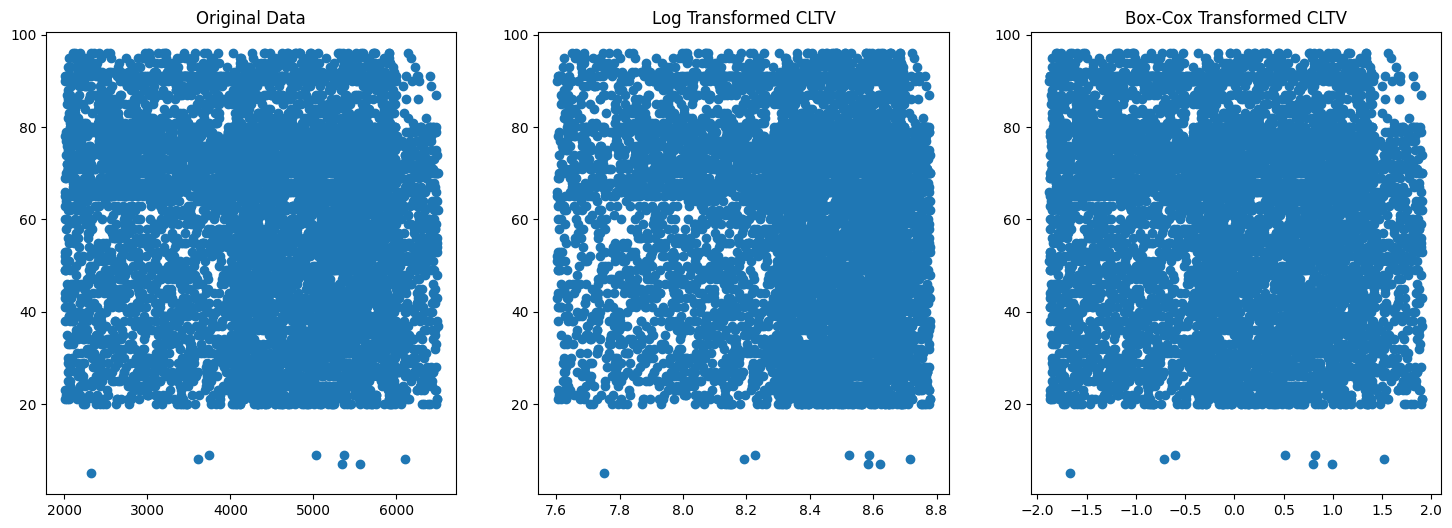

In [85]:
# import pandas as pd
# import numpy as np
# from scipy import stats
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.preprocessing import StandardScaler, PowerTransformer

# # Sample Data (Create some skewed data for demonstration)
# # np.random.seed(0)
# # cltv = np.exp(np.random.normal(5, 1, 500))  # Positively skewed CLTV
# # churn_score = np.random.normal(0.5, 0.2, 500) # reasonably normal churn score
# # df = pd.DataFrame({'cltv': cltv, 'churn_score': churn_score})

# # 1. Check for Normality (Visual and Statistical):

# # Histograms
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# sns.histplot(df['cltv'], kde=True)
# plt.title('CLTV Distribution')
# plt.subplot(1, 2, 2)
# sns.histplot(df['churn_score'], kde=True)
# plt.title('Churn Score Distribution')
# plt.show()


# # # Q-Q Plots
# # import statsmodels.api as sm
# # plt.figure(figsize=(12, 6))
# # plt.subplot(1, 2, 1)
# # sm.qqplot(df['cltv'], line='s')
# # plt.title('CLTV Q-Q Plot')
# # plt.subplot(1, 2, 2)
# # sm.qqplot(df['churn_score'], line='s')
# # plt.title('Churn Score Q-Q Plot')
# # plt.show()

# # Shapiro-Wilk Test
# cltv_shapiro = stats.shapiro(df['cltv'])
# churn_shapiro = stats.shapiro(df['churn_score'])
# print(f"CLTV Shapiro-Wilk: {cltv_shapiro}")
# print(f"Churn Shapiro-Wilk: {churn_shapiro}")

# # 2. Transformations:

# # Log Transformation (for CLTV)
# df['log_cltv'] = np.log1p(df['cltv'])  # Use log1p to handle 0 values if present
# df['log_churn_score'] = np.log1p(df['churn_score'])  # Use log1p to handle 0 values if present


# # Power Transformation (Box-Cox, Yeo-Johnson)
# pt = PowerTransformer()
# df['boxcox_cltv'] = pt.fit_transform(df[['cltv']])
# df['boxcox_churn_score'] = pt.fit_transform(df[['churn_score']])

# # 3. Scaling (Standardization):
# scaler = StandardScaler()
# df['scaled_log_cltv'] = scaler.fit_transform(df[['log_cltv']])
# df['scaled_churn_score'] = scaler.fit_transform(df[['churn_score']])

# # 4. Correlation Analysis (Before and After Transformations):

# # Before Transformations
# pearson_original = stats.pearsonr(df['cltv'], df['churn_score'])
# spearman_original = stats.spearmanr(df['cltv'], df['churn_score'])
# print("\nOriginal Data:")
# print(f"Pearson: {pearson_original}")
# print(f"Spearman: {spearman_original}")

# # Histograms
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# sns.histplot(df['log_cltv'], kde=True)
# plt.title('CLTV Distribution')
# plt.subplot(1, 2, 2)
# sns.histplot(df['log_churn_score'], kde=True)
# plt.title('Churn Score Distribution')
# plt.show()

# # Histograms
# plt.figure(figsize=(12, 6))
# plt.subplot(1, 2, 1)
# sns.histplot(df['boxcox_cltv'], kde=True)
# plt.title('CLTV Distribution')
# plt.subplot(1, 2, 2)
# sns.histplot(df['boxcox_churn_score'], kde=True)
# plt.title('Churn Score Distribution')
# plt.show()


# # After Log Transformation and Scaling
# pearson_log_scaled = stats.pearsonr(df['scaled_log_cltv'], df['scaled_churn_score'])
# spearman_log_scaled = stats.spearmanr(df['scaled_log_cltv'], df['scaled_churn_score'])
# print("\nAfter Log Transformation and Scaling:")
# print(f"Pearson: {pearson_log_scaled}")
# print(f"Spearman: {spearman_log_scaled}")

# # After Box-Cox Transformation and Scaling
# pearson_boxcox_scaled = stats.pearsonr(df['boxcox_cltv'], df['scaled_churn_score'])
# spearman_boxcox_scaled = stats.spearmanr(df['boxcox_cltv'], df['scaled_churn_score'])
# print("\nAfter Box-Cox Transformation and Scaling:")
# print(f"Pearson: {pearson_boxcox_scaled}")
# print(f"Spearman: {spearman_boxcox_scaled}")


# # Scatter Plots (Before and After Transformations)
# plt.figure(figsize=(18, 6))

# plt.subplot(1, 3, 1)
# plt.scatter(df['cltv'], df['churn_score'])
# plt.title('Original Data')

# plt.subplot(1, 3, 2)
# plt.scatter(df['log_cltv'], df['churn_score'])
# plt.title('Log Transformed CLTV')

# plt.subplot(1, 3, 3)
# plt.scatter(df['boxcox_cltv'], df['churn_score'])
# plt.title('Box-Cox Transformed CLTV')
# plt.show()